# 02 — Exploratory Data Analysis (EDA)

**Project:** Network Intrusion Detection using ML with Explainable AI  
**Program:** IEEE CS Bangalore Chapter — SIMP 2026  
**Team:** Piyush M. Borkar, Varun Gada  

---

### Notebook Objectives
1. Analyze class balance (binary & multiclass)
2. Visualize feature distributions
3. Compute and plot correlation heatmap
4. Analyze categorical features vs attack categories
5. Detect outliers in key features
6. Derive insights to guide feature engineering and model selection

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

# Output directories
GRAPHS_DIR = '../results/graphs'
os.makedirs(GRAPHS_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


## 2. Load Processed Data

In [2]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()

df_train = pd.read_csv(os.path.join(BASE_DIR, 'data', 'processed', 'train_cleaned.csv'))
df_test  = pd.read_csv(os.path.join(BASE_DIR, 'data', 'processed', 'test_cleaned.csv'))

print('Train shape:', df_train.shape)
print('Test shape :', df_test.shape)
df_train.head(3)

Train shape: (125973, 125)
Test shape : (22544, 125)


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,491,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
1,0,146,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
2,0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,True,False,False,False,False,False


## 3. Class Balance Analysis

Understanding class distribution is critical — imbalanced classes can heavily bias model performance.

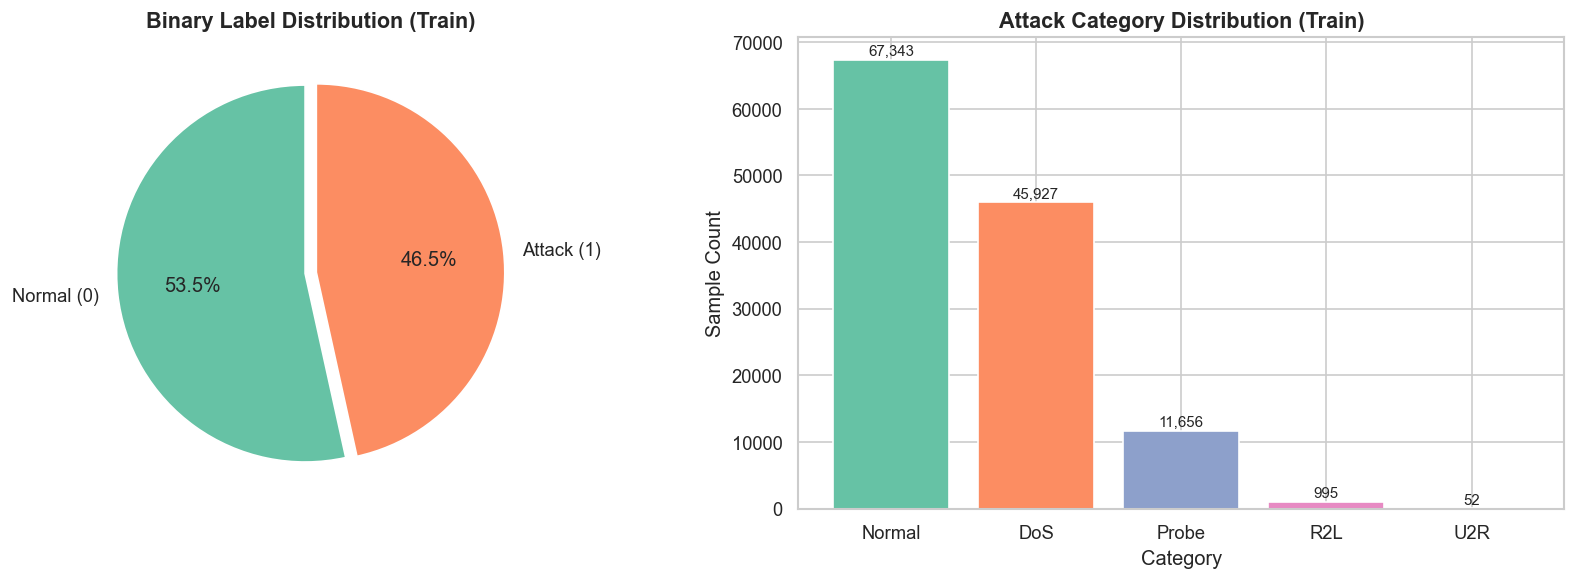

Saved: results/graphs/class_balance.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Binary label ---
binary_counts = df_train['binary_label'].value_counts()
labels_bin    = ['Normal (0)', 'Attack (1)']
axes[0].pie(
    binary_counts.values,
    labels=labels_bin,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2', 2),
    startangle=90,
    explode=(0.03, 0.03)
)
axes[0].set_title('Binary Label Distribution (Train)', fontsize=13, fontweight='bold')

# --- Multiclass (attack category) ---
cat_counts = df_train['attack_category'].value_counts()
bars = axes[1].bar(cat_counts.index, cat_counts.values,
                   color=sns.color_palette('Set2', len(cat_counts)), edgecolor='white')
axes[1].set_title('Attack Category Distribution (Train)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Sample Count')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{bar.get_height():,}',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/class_balance.png', bbox_inches='tight')
plt.show()
print('Saved: results/graphs/class_balance.png')

In [4]:
# Imbalance ratio
print('=== Binary Label Counts ===')
print(df_train['binary_label'].value_counts())
ratio = df_train['binary_label'].value_counts()[1] / df_train['binary_label'].value_counts()[0]
print(f'\nAttack:Normal ratio = {ratio:.2f}')

print('\n=== Attack Category Counts ===')
print(df_train['attack_category'].value_counts())

print('\n=== Test Set — Attack Category ===')
print(df_test['attack_category'].value_counts())

=== Binary Label Counts ===
binary_label
0    67343
1    58630
Name: count, dtype: int64

Attack:Normal ratio = 0.87

=== Attack Category Counts ===
attack_category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

=== Test Set — Attack Category ===
attack_category
Normal     9711
DoS        7458
R2L        2885
Probe      2421
U2R          67
Unknown       2
Name: count, dtype: int64


## 4. Numerical Feature Distributions

We examine the distribution of key numerical features to identify skewness, zero-heavy columns, and scaling needs.

In [5]:
# Select only the original numerical feature columns (exclude encoded, label columns)
EXCLUDE = ['label', 'attack_category', 'binary_label']
encoded_cols = [c for c in df_train.columns if any(c.startswith(p+'_') for p in ['protocol_type','service','flag'])]
EXCLUDE += encoded_cols

num_cols = [c for c in df_train.columns if c not in EXCLUDE and df_train[c].dtype != 'object']
print(f'Numerical features: {len(num_cols)}')
print(num_cols)

Numerical features: 38
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


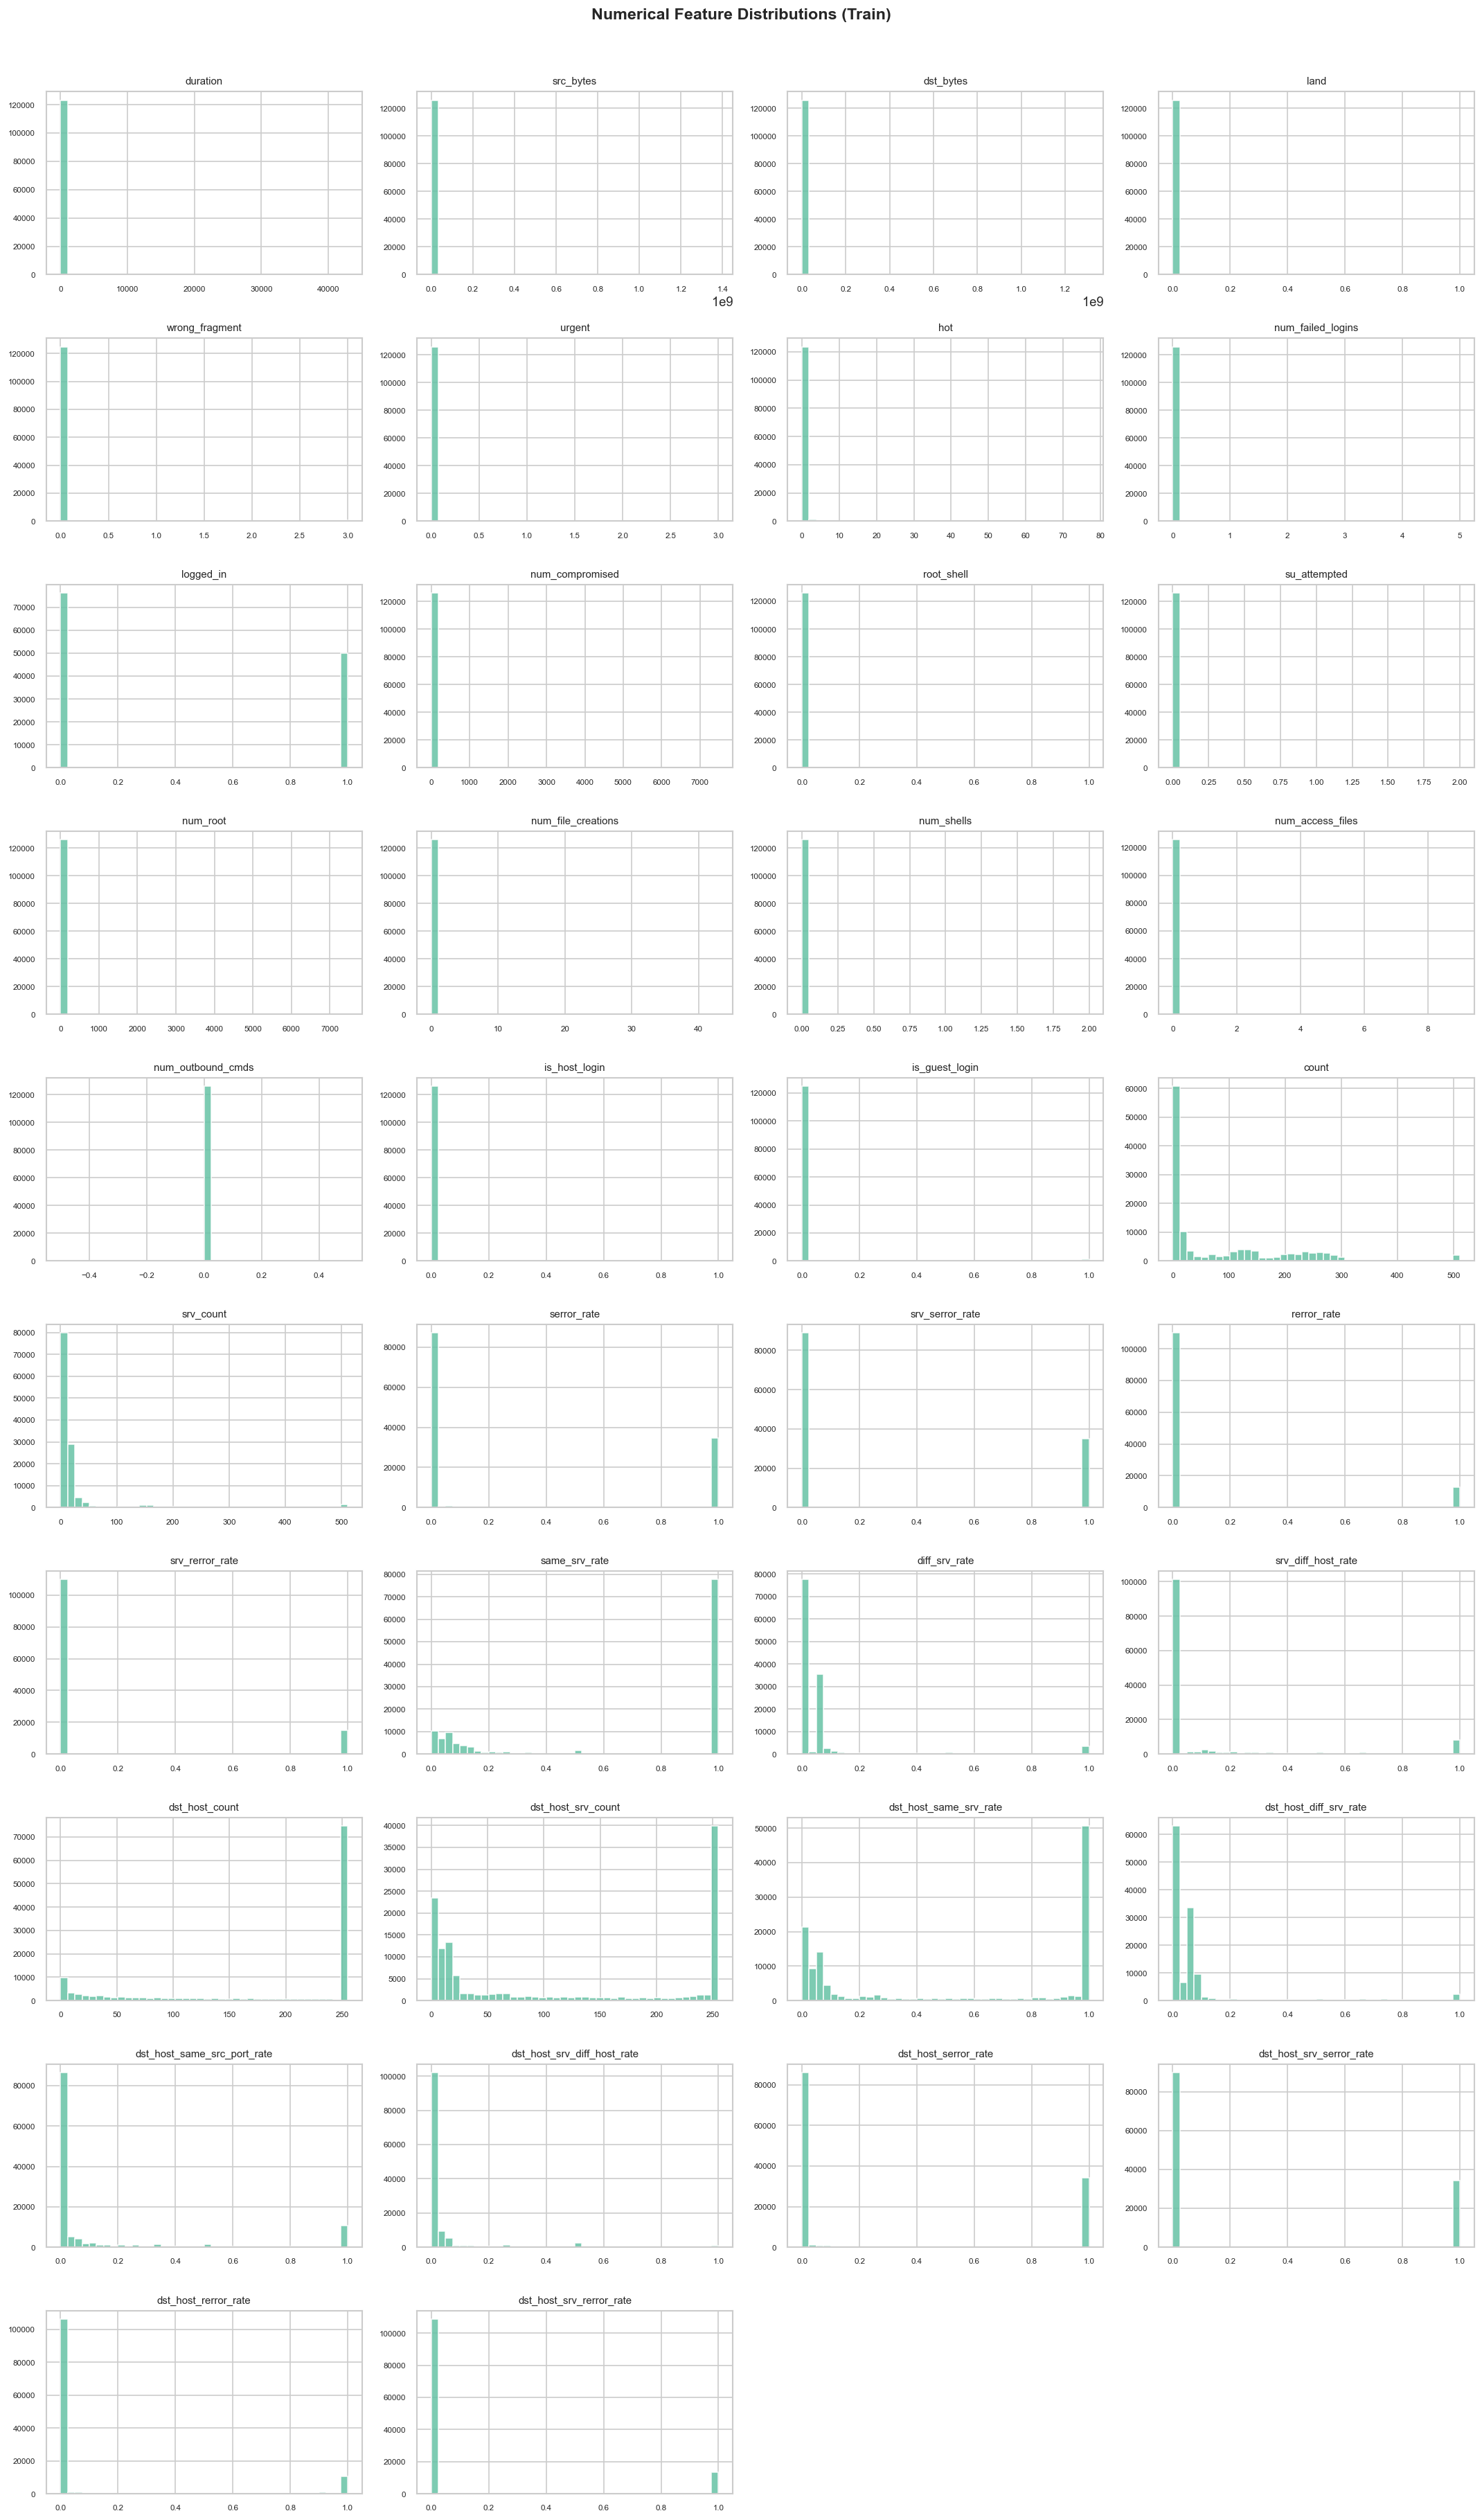

Saved: results/graphs/feature_distributions.png


In [6]:
# Histograms for all numerical features
n_cols = 4
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_train[col], bins=40, color=sns.color_palette('Set2')[0],
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=7)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions (Train)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/feature_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: results/graphs/feature_distributions.png')

In [7]:
# Skewness analysis — identify highly skewed features
skewness = df_train[num_cols].skew().sort_values(ascending=False)
print('Top 10 Most Skewed Features:')
print(skewness.head(10))

# Features with > 90% zero values
zero_heavy = [(c, (df_train[c] == 0).mean() * 100) for c in num_cols]
zero_heavy = sorted(zero_heavy, key=lambda x: x[1], reverse=True)
print('\nFeatures with >90% Zero Values:')
for col, pct in zero_heavy:
    if pct > 90:
        print(f'  {col}: {pct:.1f}% zeros')

Top 10 Most Skewed Features:
is_host_login         354.926753
dst_bytes             290.052911
num_compromised       250.107883
num_root              236.913724
src_bytes             190.669347
urgent                149.914509
land                   70.965063
num_shells             59.592151
num_file_creations     55.665341
num_failed_logins      53.764424
dtype: float64

Features with >90% Zero Values:
  num_outbound_cmds: 100.0% zeros
  is_host_login: 100.0% zeros
  urgent: 100.0% zeros
  land: 100.0% zeros
  num_shells: 100.0% zeros
  su_attempted: 99.9% zeros
  num_failed_logins: 99.9% zeros
  root_shell: 99.9% zeros
  num_file_creations: 99.8% zeros
  num_access_files: 99.7% zeros
  num_root: 99.5% zeros
  wrong_fragment: 99.1% zeros
  is_guest_login: 99.1% zeros
  num_compromised: 99.0% zeros
  hot: 97.9% zeros
  duration: 92.0% zeros


## 5. Correlation Heatmap

Identifying highly correlated features helps reduce redundancy and guides feature selection.

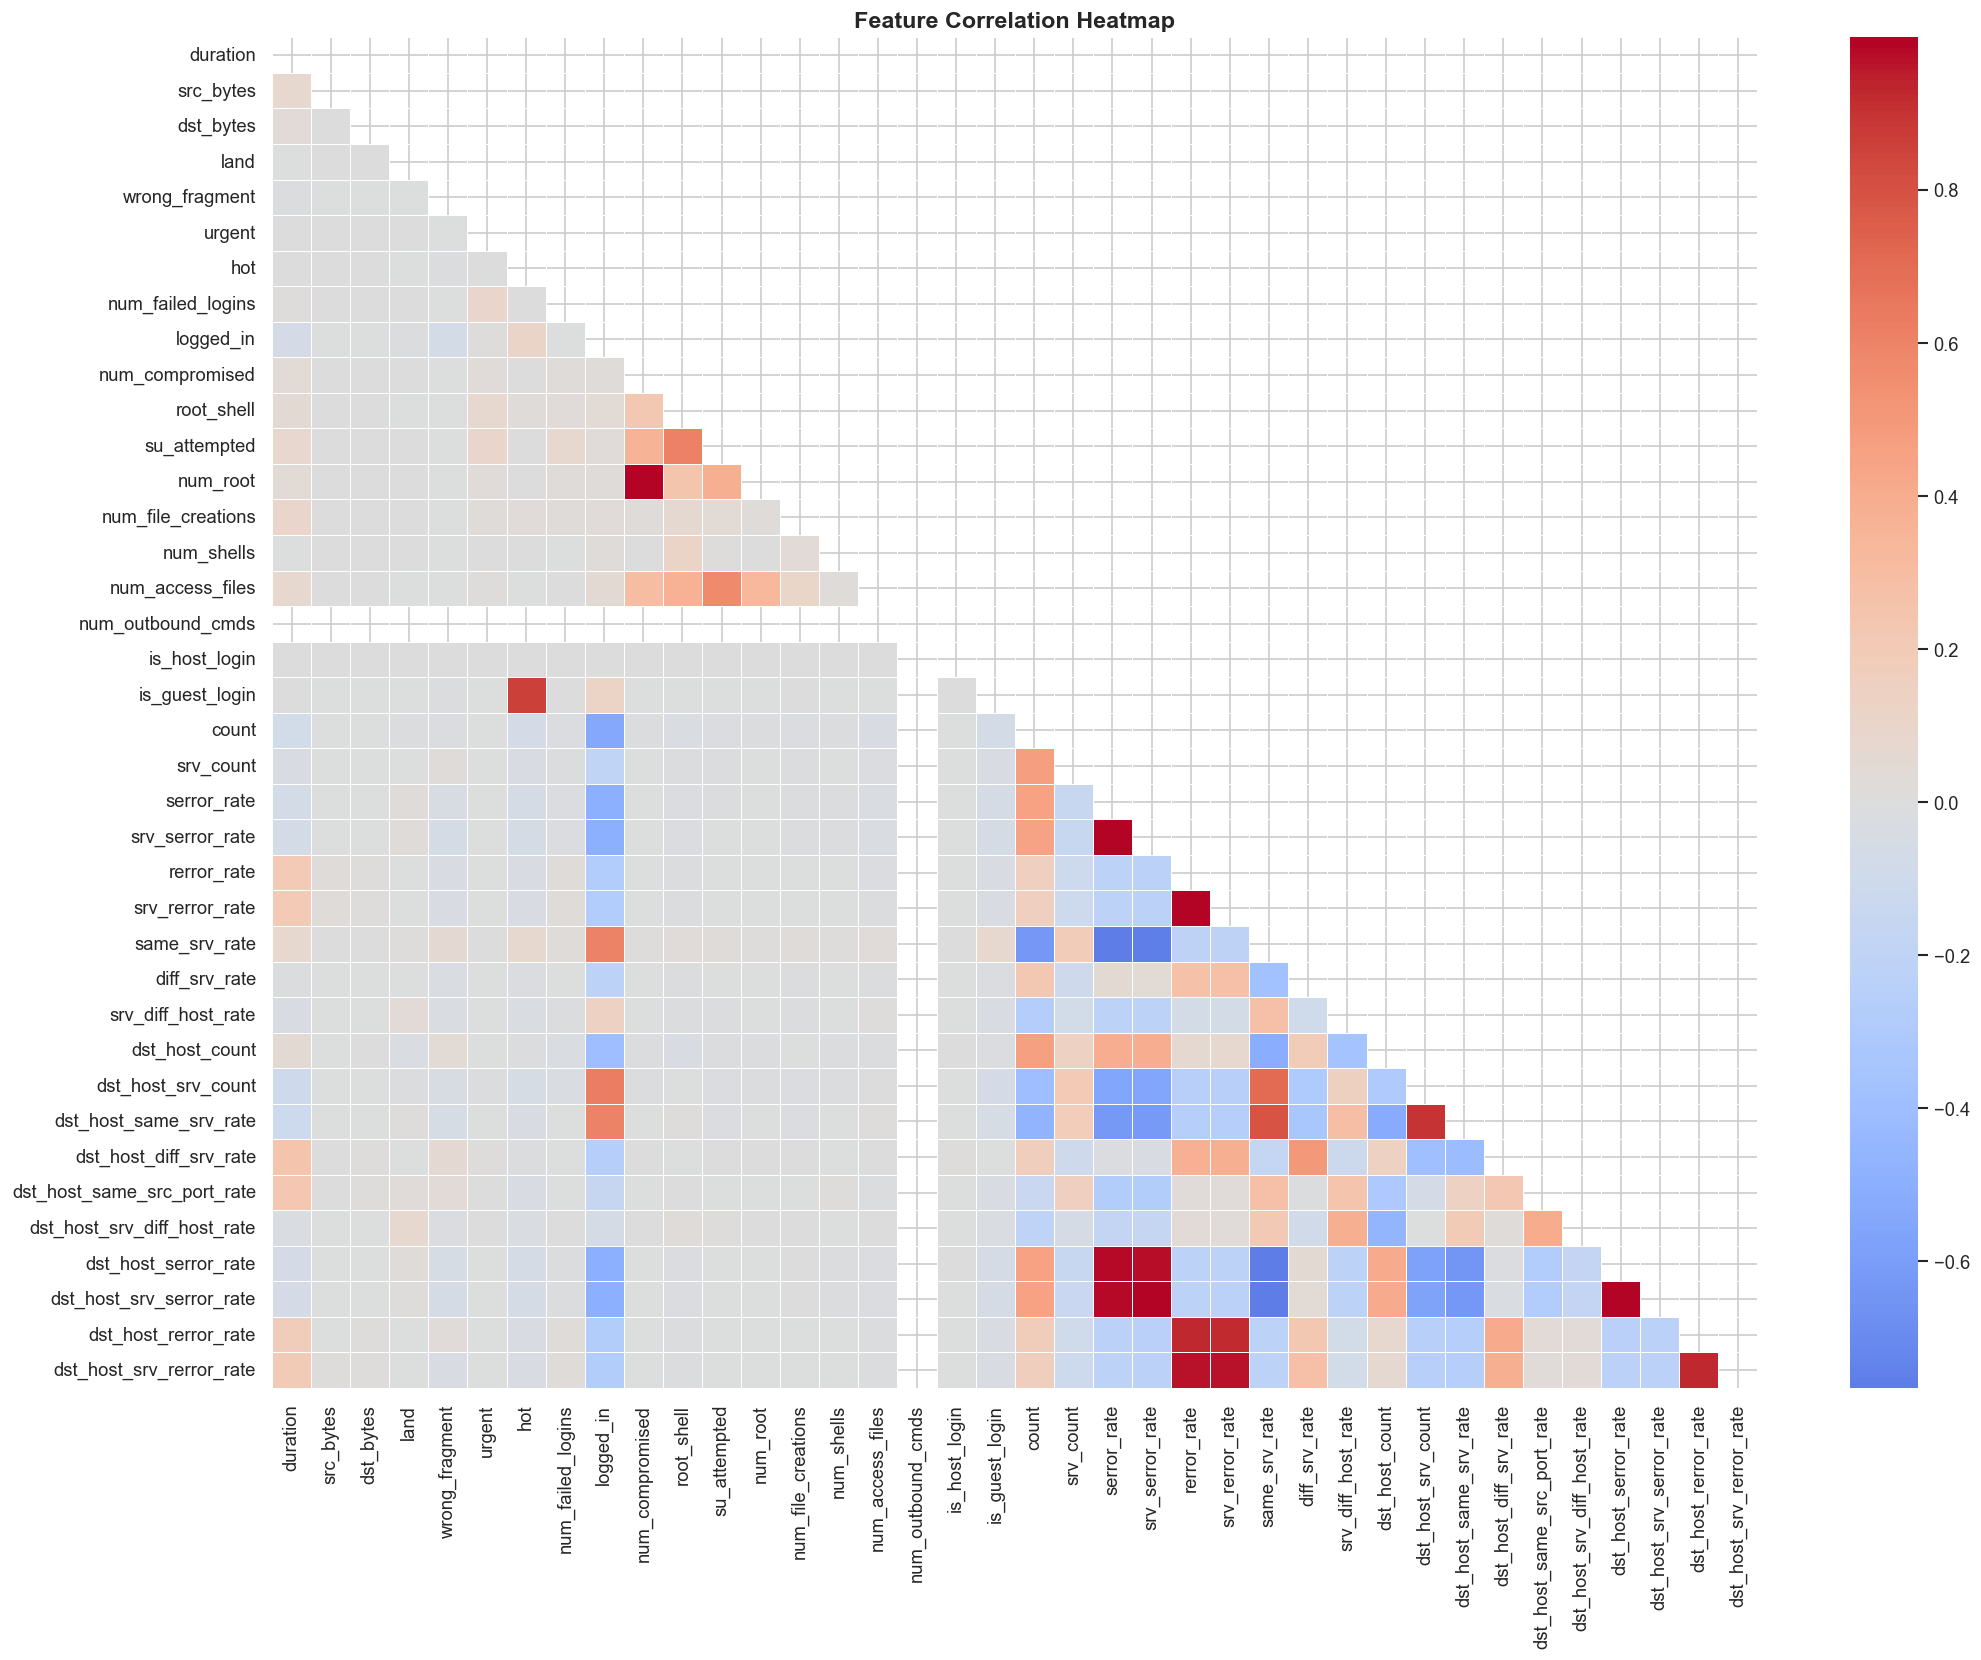

Saved: results/graphs/correlation_heatmap.png


In [8]:
corr_matrix = df_train[num_cols].corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    ax=ax
)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: results/graphs/correlation_heatmap.png')

In [9]:
# Find highly correlated pairs (|r| > 0.90)
threshold = 0.90
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > threshold:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(val, 3)))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Feature A', 'Feature B', 'Correlation'])
high_corr_df = high_corr_df.sort_values('Correlation', ascending=False)

print(f'Feature pairs with |correlation| > {threshold}:')
print(high_corr_df.to_string(index=False))

Feature pairs with |correlation| > 0.9:
           Feature A                Feature B  Correlation
     num_compromised                 num_root        0.999
         serror_rate          srv_serror_rate        0.993
         rerror_rate          srv_rerror_rate        0.989
     srv_serror_rate dst_host_srv_serror_rate        0.986
dst_host_serror_rate dst_host_srv_serror_rate        0.985
         serror_rate dst_host_srv_serror_rate        0.981
         serror_rate     dst_host_serror_rate        0.979
     srv_serror_rate     dst_host_serror_rate        0.978
     srv_rerror_rate dst_host_srv_rerror_rate        0.970
         rerror_rate dst_host_srv_rerror_rate        0.964
         rerror_rate     dst_host_rerror_rate        0.927
dst_host_rerror_rate dst_host_srv_rerror_rate        0.925
     srv_rerror_rate     dst_host_rerror_rate        0.918


## 6. Categorical Features vs Attack Category

Analyzing how `protocol_type`, `service`, and `flag` distribute across attack categories.

In [10]:
# Reconstruct original categorical columns from one-hot for visualization
def reconstruct_categorical(df, prefix):
    cols = [c for c in df.columns if c.startswith(prefix + '_')]
    return df[cols].idxmax(axis=1).str.replace(prefix + '_', '', regex=False)

df_viz = df_train.copy()
df_viz['protocol_type'] = reconstruct_categorical(df_train, 'protocol_type')
df_viz['service']       = reconstruct_categorical(df_train, 'service')
df_viz['flag']          = reconstruct_categorical(df_train, 'flag')

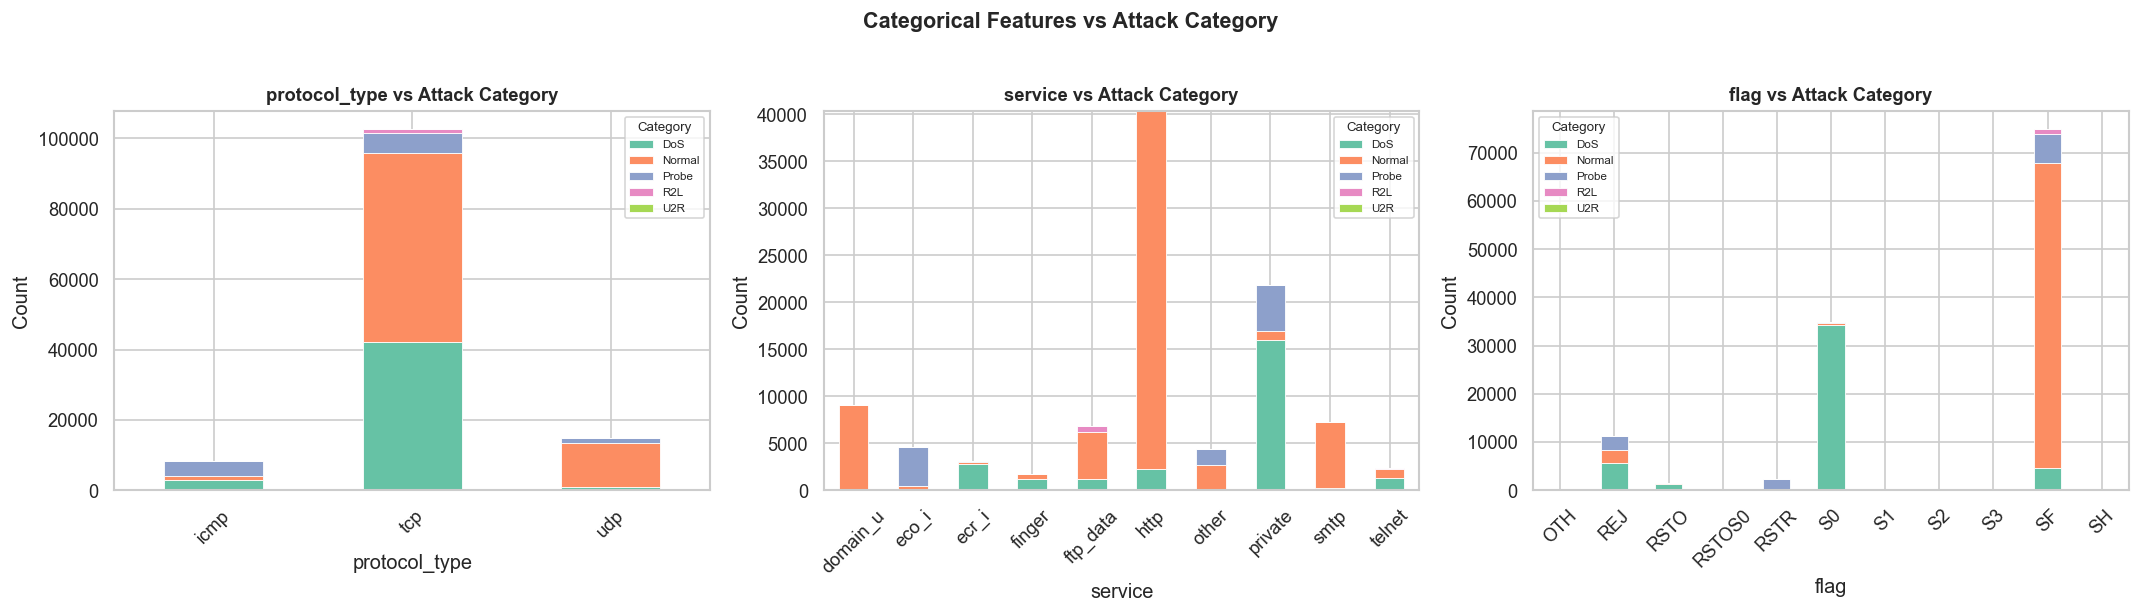

Saved: results/graphs/categorical_vs_attack.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['protocol_type', 'service', 'flag']):
    if col == 'service':
        # Top 10 services only to keep it readable
        top_services = df_viz['service'].value_counts().head(10).index
        data = df_viz[df_viz['service'].isin(top_services)]
    else:
        data = df_viz

    ct = pd.crosstab(data[col], data['attack_category'])
    ct.plot(kind='bar', ax=ax, stacked=True,
            color=sns.color_palette('Set2', ct.shape[1]),
            edgecolor='white', linewidth=0.5)
    ax.set_title(f'{col} vs Attack Category', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Category', fontsize=7, title_fontsize=8)

plt.suptitle('Categorical Features vs Attack Category', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/categorical_vs_attack.png', bbox_inches='tight')
plt.show()
print('Saved: results/graphs/categorical_vs_attack.png')

## 7. Key Feature Analysis by Attack Category

Examining how important traffic features differ across attack types.

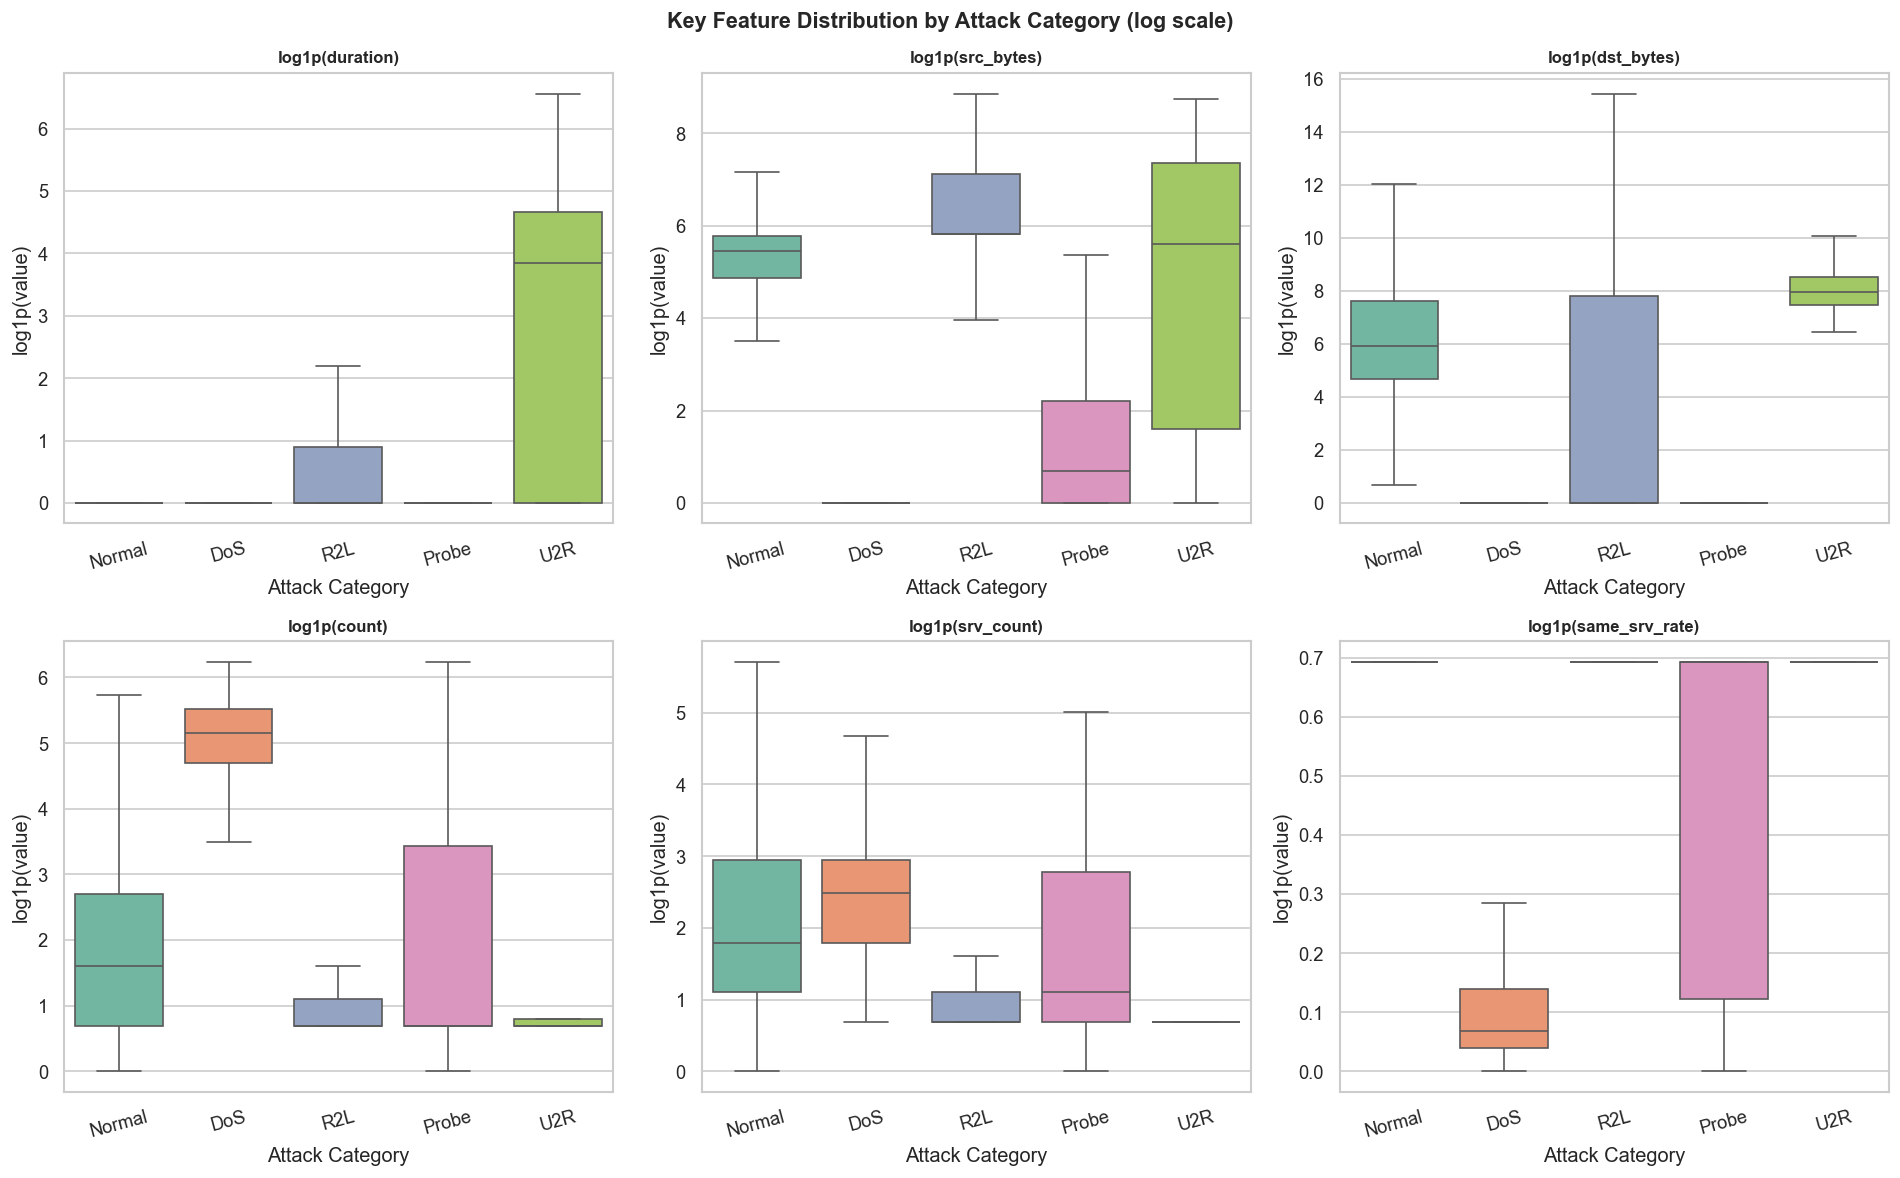

Saved: results/graphs/key_features_by_category.png


In [12]:
KEY_FEATURES = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count', 'same_srv_rate']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(KEY_FEATURES):
    # Log scale for better visibility of skewed features
    data_plot = df_train[['attack_category', feat]].copy()
    data_plot[feat] = np.log1p(data_plot[feat])

    sns.boxplot(
        data=data_plot,
        x='attack_category',
        y=feat,
        palette='Set2',
        ax=axes[i],
        showfliers=False
    )
    axes[i].set_title(f'log1p({feat})', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Attack Category')
    axes[i].set_ylabel('log1p(value)')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Key Feature Distribution by Attack Category (log scale)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/key_features_by_category.png', bbox_inches='tight')
plt.show()
print('Saved: results/graphs/key_features_by_category.png')

## 8. Outlier Detection

Using IQR method to quantify outliers in key numerical features.

Top 15 Features by Outlier Count (IQR method):
srv_diff_host_rate             28399
dst_host_same_src_port_rate    25052
dst_bytes                      23579
dst_host_rerror_rate           22795
dst_host_srv_rerror_rate       19357
srv_rerror_rate                16206
rerror_rate                    16190
src_bytes                      13840
srv_count                      12054
dst_host_srv_diff_host_rate    11682
dst_host_diff_srv_rate         10550
duration                       10018
diff_srv_rate                   7788
count                           3157
hot                             2671
dtype: int64


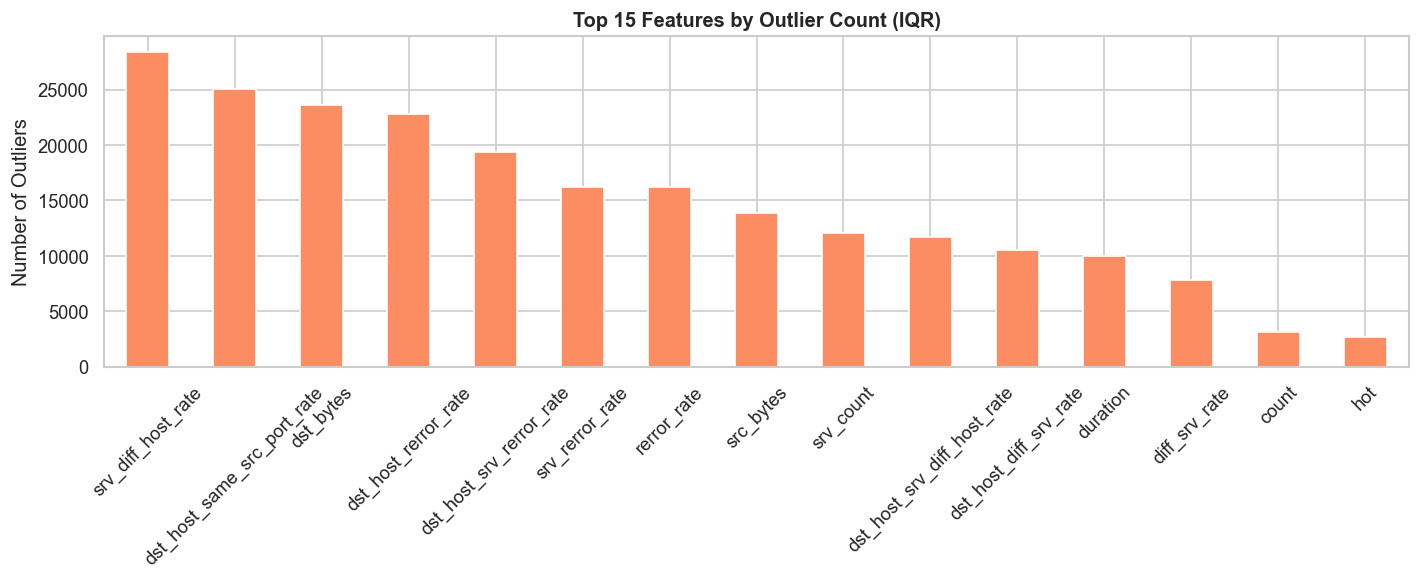

Saved: results/graphs/outlier_counts.png


In [13]:
def iqr_outlier_count(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR    = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

outlier_counts = pd.Series(
    {col: iqr_outlier_count(df_train[col]) for col in num_cols}
).sort_values(ascending=False)

print('Top 15 Features by Outlier Count (IQR method):')
print(outlier_counts.head(15))

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
outlier_counts.head(15).plot(kind='bar', ax=ax,
                              color=sns.color_palette('Set2')[1], edgecolor='white')
ax.set_title('Top 15 Features by Outlier Count (IQR)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Outliers')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/outlier_counts.png', bbox_inches='tight')
plt.show()
print('Saved: results/graphs/outlier_counts.png')

## 9. Feature-Label Correlation

Checking how strongly each numerical feature correlates with the binary label — useful for feature selection.

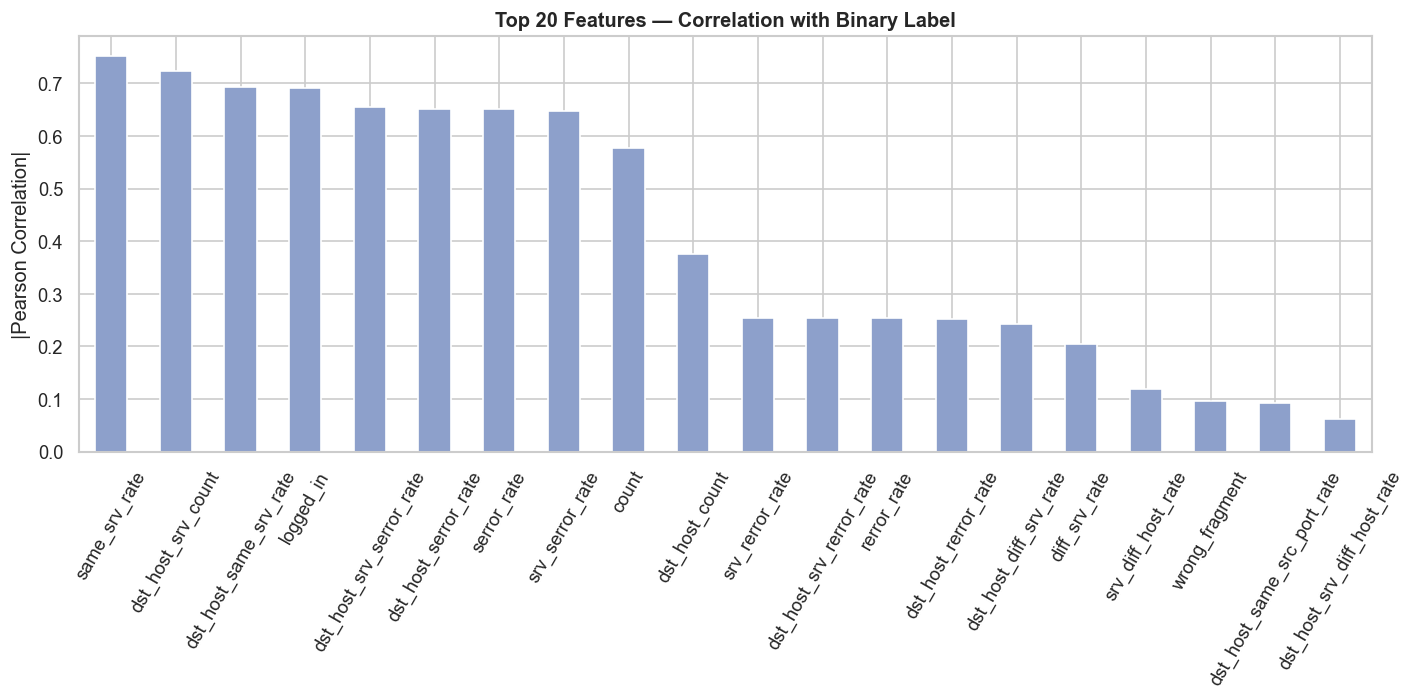

Top 10 most correlated features with the binary label:
same_srv_rate               0.751913
dst_host_srv_count          0.722535
dst_host_same_srv_rate      0.693803
logged_in                   0.690171
dst_host_srv_serror_rate    0.654985
dst_host_serror_rate        0.651842
serror_rate                 0.650652
srv_serror_rate             0.648289
count                       0.576444
dst_host_count              0.375052
Name: binary_label, dtype: float64


In [14]:
feat_label_corr = df_train[num_cols + ['binary_label']].corr()['binary_label'].drop('binary_label')
feat_label_corr = feat_label_corr.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
feat_label_corr.head(20).plot(kind='bar', ax=ax,
                               color=sns.color_palette('Set2')[2], edgecolor='white')
ax.set_title('Top 20 Features — Correlation with Binary Label', fontsize=12, fontweight='bold')
ax.set_ylabel('|Pearson Correlation|')
ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/feature_label_correlation.png', bbox_inches='tight')
plt.show()

print('Top 10 most correlated features with the binary label:')
print(feat_label_corr.head(10))

## 10. EDA Summary & Insights

Document key observations here — these directly feed into the research paper.

In [15]:
print('=' * 60)
print('EDA SUMMARY')
print('=' * 60)

print(f"""
Dataset Overview:
  Train samples : {len(df_train):,}
  Test samples  : {len(df_test):,}
  Features      : {len(num_cols)} numerical + encoded categoricals

Class Distribution:
  Binary  — Normal: {(df_train['binary_label']==0).sum():,} | Attack: {(df_train['binary_label']==1).sum():,}
  Multiclass categories: {df_train['attack_category'].nunique()} classes
    {df_train['attack_category'].value_counts().to_string()}

Key Observations:
  - Several features have >90% zero values (sparse features)
  - src_bytes and dst_bytes are highly skewed — log scaling recommended
  - Some feature pairs have high correlation (>0.90) — consider dropping redundant ones
  - DoS attacks are the dominant attack class in both train and test sets
  - U2R and R2L are significantly underrepresented — class imbalance handling needed
""")

print('Graphs saved to results/graphs/')

EDA SUMMARY

Dataset Overview:
  Train samples : 125,973
  Test samples  : 22,544
  Features      : 38 numerical + encoded categoricals

Class Distribution:
  Binary  — Normal: 67,343 | Attack: 58,630
  Multiclass categories: 5 classes
    attack_category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52

Key Observations:
  - Several features have >90% zero values (sparse features)
  - src_bytes and dst_bytes are highly skewed — log scaling recommended
  - Some feature pairs have high correlation (>0.90) — consider dropping redundant ones
  - DoS attacks are the dominant attack class in both train and test sets
  - U2R and R2L are significantly underrepresented — class imbalance handling needed

Graphs saved to results/graphs/


---

## Checklist

| Step | Action | Status |
|------|--------|--------|
| 1 | Class balance analysis | ✅ |
| 2 | Feature distributions & skewness | ✅ |
| 3 | Correlation heatmap | ✅ |
| 4 | Categorical features vs attack category | ✅ |
| 5 | Key feature boxplots by category | ✅ |
| 6 | Outlier detection (IQR) | ✅ |
| 7 | Feature-label correlation ranking | ✅ |
